# Paradigma 3: Donut Fine-Tuning (Colab Pro)

**Setup:** Runtime → Change runtime type → **A100 GPU** (sau V100/T4 High-RAM)

Acest notebook:
1. Antreneaza Donut pe date curate → evalueaza pe test curat
2. Re-antreneaza Donut pe date curate + augmentate → evalueaza pe test augmentat
3. Compara cele doua rezultate

In [1]:
# 1. Install dependencies
!pip install -q transformers datasets accelerate sentencepiece pypdfium2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 50.8 MB/s eta 0:00:00


In [2]:
# 2a. Mount Google Drive (FAST — recommended for large files)
# Upload all files to a folder in Google Drive first (e.g. My Drive/disertatie/)
from google.colab import drive
drive.mount('/content/drive')

# Set path to your folder in Drive
DRIVE_FOLDER = '/content/drive/MyDrive/disertatie'

# Check what's there
import os
if os.path.exists(DRIVE_FOLDER):
    print(f'Files in {DRIVE_FOLDER}:')
    for f in sorted(os.listdir(DRIVE_FOLDER)):
        size = os.path.getsize(os.path.join(DRIVE_FOLDER, f)) / 1024 / 1024
        print(f'  {f} ({size:.1f} MB)')
else:
    print(f'Folder not found: {DRIVE_FOLDER}')
    print('Create it in Google Drive and upload your files there.')

Mounted at /content/drive
Files in /content/drive/MyDrive/disertatie:
  attachments.zip (9.7 MB)
  attachments_img_medium.zip (1087.1 MB)
  test.csv (0.0 MB)
  test_image_medium.csv (0.0 MB)
  train.csv (0.2 MB)
  train_image_medium.csv (0.2 MB)
  val.csv (0.0 MB)


In [3]:
# 2b. Copy files from Drive and extract zips
import shutil, zipfile

# Copy CSVs
for f in ['train.csv', 'val.csv', 'test.csv',
          'train_image_medium.csv', 'test_image_medium.csv']:
    src = os.path.join(DRIVE_FOLDER, f)
    if os.path.exists(src):
        shutil.copy2(src, f)
        print(f'Copied: {f}')
    else:
        print(f'MISSING: {f}')

# Extract clean attachments
zip_path = os.path.join(DRIVE_FOLDER, 'attachments.zip')
if os.path.exists(zip_path):
    print(f'\nExtracting attachments.zip...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('.')
    print(f'  Done! attachments/ has {len(os.listdir("attachments"))} files')
else:
    print(f'MISSING: attachments.zip')

Copied: train.csv
Copied: val.csv
Copied: test.csv
Copied: train_image_medium.csv
Copied: test_image_medium.csv

Extracting attachments.zip...
  Done! attachments/ has 310 files


In [4]:
# 2c. Extract augmented images + verify everything
import zipfile

zip_path = os.path.join(DRIVE_FOLDER, 'attachments_img_medium.zip')
if os.path.exists(zip_path):
    print(f'Extracting attachments_img_medium.zip...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('.')
    print(f'  Done!')
else:
    print(f'MISSING: attachments_img_medium.zip')

# Find augmented images (handle nested folders)
aug_img_dir = None
for root, dirs, flist in os.walk('.'):
    if flist and any(f.endswith('.png') for f in flist) and 'img_medium' in root:
        aug_img_dir = root
        break

# Final verification
print(f'\n{"="*50}')
print('VERIFICATION')
print(f'{"="*50}')

print(f'\nClean data:')
for f in ['train.csv', 'val.csv', 'test.csv']:
    print(f'  {"OK" if os.path.exists(f) else "MISSING"}: {f}')
if os.path.exists('attachments'):
    print(f'  OK: attachments/ ({len(os.listdir("attachments"))} files)')
else:
    print(f'  MISSING: attachments/')

print(f'\nAugmented data:')
for f in ['train_image_medium.csv', 'test_image_medium.csv']:
    print(f'  {"OK" if os.path.exists(f) else "MISSING"}: {f}')
if aug_img_dir:
    print(f'  OK: {aug_img_dir} ({len(os.listdir(aug_img_dir))} files)')
else:
    print(f'  MISSING: augmented images not found')

print(f'\nAll OK!' if all([
    os.path.exists('train.csv'),
    os.path.exists('attachments'),
    os.path.exists('train_image_medium.csv'),
    aug_img_dir is not None,
]) else '\nSome files missing — check above')

Extracting attachments_img_medium.zip...
  Done!

VERIFICATION

Clean data:
  OK: train.csv
  OK: val.csv
  OK: test.csv
  OK: attachments/ (310 files)

Augmented data:
  OK: train_image_medium.csv
  OK: test_image_medium.csv
  OK: ./attachments_img_medium (268 files)

All OK!


In [5]:
# 3. Prepare dataset in Donut format
import csv, json, os, re
import numpy as np
from PIL import Image
import pypdfium2 as pdfium

def load_split(path):
    records = []
    with open(path, 'r', encoding='utf-8-sig') as f:
        for row in csv.DictReader(f):
            records.append(row)
    return records

def pdf_to_image(pdf_path, dpi=150):
    pdf = pdfium.PdfDocument(pdf_path)
    page = pdf[0]
    bitmap = page.render(scale=dpi/72)
    img = bitmap.to_pil()
    pdf.close()
    return img

def load_doc_image(path):
    if path.lower().endswith('.pdf'):
        return pdf_to_image(path)
    return Image.open(path).convert('RGB')

def fix_path(path):
    """Fix Windows paths and find files on Colab."""
    if not path:
        return path
    if os.path.exists(path):
        return path
    filename = os.path.basename(path.replace('\\', '/'))
    # Search common locations
    candidates = [
        os.path.join('attachments', filename),
    ]
    # Add augmented image directories
    for root, dirs, flist in os.walk('.'):
        if 'img_medium' in root and filename in flist:
            return os.path.join(root, filename)
    for c in candidates:
        if os.path.exists(c):
            return c
    return path

def build_donut_dataset(records, split_name, do_fix_path=False):
    dataset = []
    skipped = 0
    for rec in records:
        attach_path = rec.get('attachment_path', '')
        if do_fix_path:
            attach_path = fix_path(attach_path)
        if not attach_path or not os.path.exists(attach_path):
            skipped += 1
            continue
        target = {
            'amount': rec.get('doc_amount', ''),
            'currency': rec.get('doc_currency', ''),
            'doc_number': rec.get('doc_doc_number', ''),
            'date': rec.get('doc_date', ''),
        }
        target_str = (
            f'<s_amount>{target["amount"]}</s_amount>'
            f'<s_currency>{target["currency"]}</s_currency>'
            f'<s_doc_number>{target["doc_number"]}</s_doc_number>'
            f'<s_date>{target["date"]}</s_date>'
        )
        dataset.append({
            'image_path': attach_path,
            'target': target_str,
            'target_dict': target,
        })
    print(f'{split_name}: {len(dataset)} samples ({skipped} skipped)')
    return dataset

# Build clean datasets
train_records = load_split('train.csv')
val_records = load_split('val.csv')
test_records = load_split('test.csv')

train_data = build_donut_dataset(train_records, 'Clean Train')
val_data = build_donut_dataset(val_records, 'Clean Val')
test_data = build_donut_dataset(test_records, 'Clean Test')

print(f'\nTotal clean: train={len(train_data)}, val={len(val_data)}, test={len(test_data)}')

Clean Train: 213 samples (132 skipped)
Clean Val: 42 samples (27 skipped)
Clean Test: 55 samples (31 skipped)

Total clean: train=213, val=42, test=55


In [6]:
# 4. Load Donut model and processor
import torch
from transformers import DonutProcessor, VisionEncoderDecoderModel

MODEL_ID = 'naver-clova-ix/donut-base'

print(f'Loading {MODEL_ID}...')
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

processor = DonutProcessor.from_pretrained(MODEL_ID)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_ID)

# Add special tokens
special_tokens = [
    '<s_amount>', '</s_amount>',
    '<s_currency>', '</s_currency>',
    '<s_doc_number>', '</s_doc_number>',
    '<s_date>', '</s_date>',
    '<s_extract>',
]
processor.tokenizer.add_special_tokens({'additional_special_tokens': special_tokens})
model.decoder.resize_token_embeddings(len(processor.tokenizer))

model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.decoder_start_token_id = processor.tokenizer.convert_tokens_to_ids('<s_extract>')

print(f'Model loaded! Parameters: {sum(p.numel() for p in model.parameters())/1e6:.0f}M')

Loading naver-clova-ix/donut-base...
GPU: NVIDIA A100-SXM4-40GB
GPU Memory: 42.4 GB


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/362 [00:00<?, ?B/s]

The image processor of type `DonutImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


model.safetensors:   0%|          | 0.00/809M [00:00<?, ?B/s]

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
The new lm_head weights will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Model loaded! Parameters: 202M


In [7]:
# 5. Create PyTorch Dataset
from torch.utils.data import Dataset

IMAGE_SIZE = (360, 480)

class DonutDocDataset(Dataset):
    def __init__(self, data, processor, max_length=128):
        self.data = data
        self.processor = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = load_doc_image(item['image_path']).resize(IMAGE_SIZE)
        pixel_values = self.processor(image, return_tensors='pt').pixel_values.squeeze()

        target_text = '<s_extract>' + item['target'] + '</s>'
        labels = self.processor.tokenizer(
            target_text,
            add_special_tokens=False,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        ).input_ids.squeeze()
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {'pixel_values': pixel_values, 'labels': labels}

train_dataset = DonutDocDataset(train_data, processor)
val_dataset = DonutDocDataset(val_data, processor)
test_dataset = DonutDocDataset(test_data, processor)

print(f'Datasets: train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}')
sample = train_dataset[0]
print(f'Image tensor: {sample["pixel_values"].shape}')
print(f'Labels tensor: {sample["labels"].shape}')

Datasets: train=213, val=42, test=55
Image tensor: torch.Size([3, 2560, 1920])
Labels tensor: torch.Size([128])


In [8]:
# 6. Helper: training function (reused for clean and augmented)
from transformers import TrainingArguments, Trainer
import gc

def train_donut(model, train_dataset, output_dir, epochs=15, batch_size=2):
    """Train Donut model and return the trainer."""
    torch.cuda.empty_cache()
    gc.collect()

    model.to('cuda')
    model.encoder.gradient_checkpointing_enable()
    model.decoder.gradient_checkpointing_enable()

    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        gradient_accumulation_steps=max(1, 8 // batch_size),
        learning_rate=5e-5,
        weight_decay=0.01,
        warmup_steps=50,
        eval_strategy='no',
        save_strategy='no',
        logging_steps=10,
        report_to='none',
        fp16=True,
        dataloader_num_workers=2,
        seed=42,
        gradient_checkpointing=True,
        optim='adafactor',
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
    )

    mem = torch.cuda.memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU: {mem:.1f}/{total:.1f} GB  |  Samples: {len(train_dataset)}  |  Epochs: {epochs}')
    trainer.train()
    print('Training complete!')
    return trainer

In [9]:
# 7. Helper: inference function

def extract_fields_donut(image_path, model, processor):
    """Extract fields from a document image using Donut."""
    model.eval()
    image = load_doc_image(image_path).resize(IMAGE_SIZE)
    pixel_values = processor(image, return_tensors='pt').pixel_values.to('cuda')

    task_prompt = '<s_extract>'
    decoder_input_ids = processor.tokenizer(
        task_prompt, add_special_tokens=False, return_tensors='pt'
    ).input_ids.to('cuda')

    with torch.no_grad():
        outputs = model.generate(
            pixel_values,
            decoder_input_ids=decoder_input_ids,
            max_length=128,
            num_beams=1,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
        )

    raw_output = processor.tokenizer.decode(outputs[0], skip_special_tokens=False)

    result = {}
    for field in ['amount', 'currency', 'doc_number', 'date']:
        pattern = f'<s_{field}>(.*?)</s_{field}>'
        match = re.search(pattern, raw_output)
        if match:
            value = re.sub(r'</?s_\w+>', '', match.group(1)).strip()
            result[field] = value if value else None
        else:
            result[field] = None

    return result, raw_output

In [10]:
# 8. Helper: evaluation function

def fields_match(pred, gt, field_type):
    """Compare predicted and ground truth field values."""
    if pred is None or gt is None or gt == '':
        return None
    if field_type == 'amount':
        try:
            p = float(str(pred).replace(',', ''))
            g = float(str(gt).replace(',', ''))
            return abs(p - g) < max(1.0, g * 0.01)
        except (ValueError, TypeError):
            return False
    elif field_type == 'currency':
        return str(pred).upper().strip() == str(gt).upper().strip()
    elif field_type == 'doc_number':
        return re.sub(r'[-/\s]', '', str(pred).upper()) == re.sub(r'[-/\s]', '', str(gt).upper())
    elif field_type == 'date':
        return str(pred).strip() == str(gt).strip()
    return str(pred) == str(gt)


def evaluate_donut(test_data, model, processor, label=''):
    """Evaluate Donut on a test set. Returns accuracy and per-field stats."""
    print(f'Evaluating {label} ({len(test_data)} samples)...')
    fields = ['amount', 'currency', 'doc_number', 'date']
    stats = {f: {'correct': 0, 'total': 0} for f in fields}
    errors = []

    for i, item in enumerate(test_data):
        result, raw = extract_fields_donut(item['image_path'], model, processor)
        gt = item['target_dict']

        for field in fields:
            gt_val = gt.get(field, '')
            if not gt_val:
                continue
            pred_val = result.get(field)
            stats[field]['total'] += 1
            if fields_match(pred_val, gt_val, field):
                stats[field]['correct'] += 1
            elif len(errors) < 10:
                errors.append({'image': os.path.basename(item['image_path']),
                               'field': field, 'gt': gt_val, 'pred': pred_val})

        if (i + 1) % 10 == 0:
            print(f'  [{i+1}/{len(test_data)}]')

    total_c = sum(s['correct'] for s in stats.values())
    total_t = sum(s['total'] for s in stats.values())
    acc = total_c / total_t if total_t > 0 else 0

    print(f'\n=== {label} ===')
    print(f'{"Field":<15s} {"Correct":>8s} {"Total":>8s} {"Accuracy":>10s}')
    print('-' * 45)
    for f in fields:
        s = stats[f]
        fa = s['correct'] / s['total'] if s['total'] > 0 else 0
        print(f'{f:<15s} {s["correct"]:>8d} {s["total"]:>8d} {fa:>10.2%}')
    print(f'{"OVERALL":<15s} {total_c:>8d} {total_t:>8d} {acc:>10.2%}')

    if errors:
        print(f'\nSample errors:')
        for e in errors[:5]:
            print(f'  {e["image"]} | {e["field"]}: gt={e["gt"]} pred={e["pred"]}')

    return acc, stats

---
## Faza 1: Antrenare pe date curate

In [11]:
# 9. Train on CLEAN data
print('='*60)
print('PHASE 1: Training Donut on CLEAN data')
print('='*60)

trainer_clean = train_donut(model, train_dataset, './donut_clean', epochs=15)

PHASE 1: Training Donut on CLEAN data
GPU: 0.8/42.4 GB  |  Samples: 213  |  Epochs: 15


`use_cache=True` is incompatible with gradient checkpointing`. Setting `use_cache=False`...


Step,Training Loss
10,48.438742
20,38.713385
30,27.415131
40,23.323978
50,21.295284
60,18.673846
70,17.083076
80,15.080685
90,12.361539
100,10.039354


Training complete!


In [12]:
# 10. Evaluate on CLEAN test
clean_acc, clean_stats = evaluate_donut(test_data, model, processor, 'Donut on CLEAN test')
print(f'\nClean accuracy: {clean_acc:.4f}')

Evaluating Donut on CLEAN test (55 samples)...
  [10/55]
  [20/55]
  [30/55]
  [40/55]
  [50/55]

=== Donut on CLEAN test ===
Field            Correct    Total   Accuracy
---------------------------------------------
amount                55       55    100.00%
currency              55       55    100.00%
doc_number            53       55     96.36%
date                  54       55     98.18%
OVERALL              217      220     98.64%

Sample errors:
  invoice_0135.png | doc_number: gt=FV-2024-97005 pred=FV-2024-97006
  invoice_0195.pdf | doc_number: gt=F-2026-70444 pred=F-2026-76444
  price_list_0337.pdf | date: gt=2026-03-10 pred=2026-03-90

Clean accuracy: 0.9864


In [13]:
# 11. Save clean results and model
import json

clean_results = {
    'donut_clean_accuracy': float(clean_acc),
    'per_field': {f: dict(s) for f, s in clean_stats.items()},
}
with open('donut_clean_results.json', 'w') as f:
    json.dump(clean_results, f, indent=2)

# Save model weights
model.save_pretrained('./donut_clean/best_model')
processor.save_pretrained('./donut_clean/best_model')
print(f'Clean results saved: accuracy={clean_acc:.4f}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Clean results saved: accuracy=0.9864


---
## Faza 2: Re-antrenare pe date curate + augmentate

In [14]:
# 12. Build augmented datasets
print('Loading augmented data...')

aug_train_records = load_split('train_image_medium.csv')
aug_test_records = load_split('test_image_medium.csv')

# Fix paths for Colab
for rec in aug_train_records:
    rec['attachment_path'] = fix_path(rec.get('attachment_path', ''))
for rec in aug_test_records:
    rec['attachment_path'] = fix_path(rec.get('attachment_path', ''))

# Verify a sample path
sample_path = aug_train_records[0].get('attachment_path', '') if aug_train_records else ''
print(f'Sample path: {sample_path}')
print(f'Exists: {os.path.exists(sample_path)}')

aug_train_data = build_donut_dataset(aug_train_records, 'Aug Train', do_fix_path=True)
aug_test_data = build_donut_dataset(aug_test_records, 'Aug Test', do_fix_path=True)

# Combine clean + augmented train
combined_train_data = train_data + aug_train_data
print(f'\nCombined train: {len(combined_train_data)} '
      f'({len(train_data)} clean + {len(aug_train_data)} augmented)')
print(f'Aug test: {len(aug_test_data)} samples')

combined_train_dataset = DonutDocDataset(combined_train_data, processor)
aug_test_dataset = DonutDocDataset(aug_test_data, processor)

Loading augmented data...
Sample path: ./attachments_img_medium/quotation_0004.png
Exists: True
Aug Train: 213 samples (132 skipped)
Aug Test: 55 samples (31 skipped)

Combined train: 426 (213 clean + 213 augmented)
Aug test: 55 samples


In [15]:
# 13. Free old model and load fresh one for augmented training
del model
del trainer_clean
torch.cuda.empty_cache()
gc.collect()
print(f'GPU freed: {torch.cuda.memory_allocated()/1e9:.1f} GB used')

# Load fresh model
model_aug = VisionEncoderDecoderModel.from_pretrained(MODEL_ID)
processor_aug = DonutProcessor.from_pretrained(MODEL_ID)
processor_aug.tokenizer.add_special_tokens({'additional_special_tokens': special_tokens})
model_aug.decoder.resize_token_embeddings(len(processor_aug.tokenizer))
model_aug.config.pad_token_id = processor_aug.tokenizer.pad_token_id
model_aug.config.decoder_start_token_id = processor_aug.tokenizer.convert_tokens_to_ids('<s_extract>')
print('Fresh model loaded for augmented training')

GPU freed: 0.0 GB used


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Fresh model loaded for augmented training


In [16]:
# 14. Train on COMBINED data (clean + augmented)
print('='*60)
print('PHASE 2: Training Donut on CLEAN + AUGMENTED data')
print('='*60)

trainer_aug = train_donut(model_aug, combined_train_dataset, './donut_augmented', epochs=15)

PHASE 2: Training Donut on CLEAN + AUGMENTED data
GPU: 0.8/42.4 GB  |  Samples: 426  |  Epochs: 15


Step,Training Loss
10,48.509708
20,37.719943
30,27.154636
40,23.423911
50,21.819986
60,18.346275
70,17.503767
80,15.205820
90,12.958768
100,9.733253


Training complete!


In [17]:
# 15. Evaluate on AUGMENTED test
aug_acc, aug_stats = evaluate_donut(
    aug_test_data, model_aug, processor_aug, 'Donut (aug-trained) on AUGMENTED test')
print(f'\nAugmented accuracy: {aug_acc:.4f}')

Evaluating Donut (aug-trained) on AUGMENTED test (55 samples)...
  [10/55]
  [20/55]
  [30/55]
  [40/55]
  [50/55]

=== Donut (aug-trained) on AUGMENTED test ===
Field            Correct    Total   Accuracy
---------------------------------------------
amount                54       55     98.18%
currency              52       55     94.55%
doc_number            53       55     96.36%
date                  53       55     96.36%
OVERALL              212      220     96.36%

Sample errors:
  quotation_0090.png | date: gt=2025-11-11 pred=2025-11-11-11
  invoice_0135.png | date: gt=2024-11-17 pred=2024-15-17
  invoice_0129.png | doc_number: gt=FV-2024-68862 pred=FV-2024-68962
  invoice_0207.png | doc_number: gt=INV-2025-74680 pred=INV-2025-74689
  invoice_0180.png | currency: gt=GBP pred=EUR

Augmented accuracy: 0.9636


DONUT FINE-TUNING: CLEAN vs AUGMENTED
                                    Clean       Augmented
-----------------------------------------------------------------
Overall Accuracy                   98.64%          96.36%

amount                            100.00%          98.18%
currency                          100.00%          94.55%
doc_number                         96.36%          96.36%
date                               98.18%          96.36%

P1 OCR+Regex (ref)                 96.82%               —


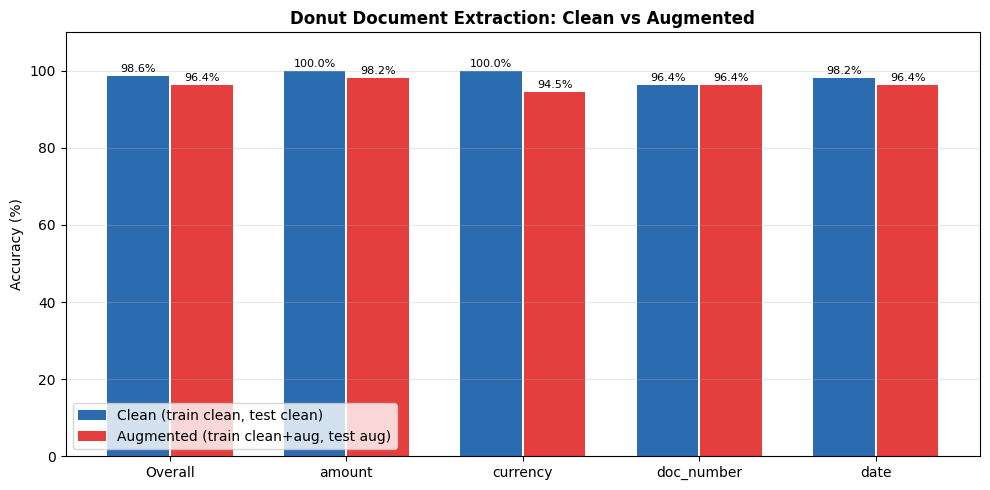

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved: donut_clean_vs_augmented.png


In [18]:
# 16. FINAL COMPARISON: Clean vs Augmented
import matplotlib.pyplot as plt
from google.colab import files

# Load clean results (in case they were lost)
if not 'clean_acc' in dir():
    with open('donut_clean_results.json', 'r') as f:
        cr = json.load(f)
    clean_acc = cr['donut_clean_accuracy']
    clean_stats = cr['per_field']

print('='*65)
print('DONUT FINE-TUNING: CLEAN vs AUGMENTED')
print('='*65)
print(f'{"":<25s} {"Clean":>15s} {"Augmented":>15s}')
print('-'*65)
print(f'{"Overall Accuracy":<25s} {clean_acc*100:>14.2f}% {aug_acc*100:>14.2f}%')
print()

fields = ['amount', 'currency', 'doc_number', 'date']
for f in fields:
    cs = clean_stats[f]
    aus = aug_stats[f]
    ca = cs['correct'] / cs['total'] if cs['total'] > 0 else 0
    aa = aus['correct'] / aus['total'] if aus['total'] > 0 else 0
    print(f'{f:<25s} {ca*100:>14.2f}% {aa*100:>14.2f}%')

print(f'\n{"P1 OCR+Regex (ref)":<25s} {"96.82%":>15s} {"—":>15s}')
print('='*65)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(fields) + 1)
clean_vals = [clean_acc * 100]
aug_vals = [aug_acc * 100]
for f in fields:
    cs = clean_stats[f]
    aus = aug_stats[f]
    clean_vals.append(cs['correct'] / cs['total'] * 100 if cs['total'] > 0 else 0)
    aug_vals.append(aus['correct'] / aus['total'] * 100 if aus['total'] > 0 else 0)

labels = ['Overall'] + fields
bars1 = ax.bar(x - 0.18, clean_vals, 0.35, label='Clean (train clean, test clean)', color='#2b6cb0')
bars2 = ax.bar(x + 0.18, aug_vals, 0.35, label='Augmented (train clean+aug, test aug)', color='#e53e3e')

for bar, v in zip(list(bars1) + list(bars2), clean_vals + aug_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Donut Document Extraction: Clean vs Augmented', fontweight='bold')
ax.legend(loc='lower left')
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('donut_clean_vs_augmented.png', dpi=200, bbox_inches='tight')
plt.show()
files.download('donut_clean_vs_augmented.png')
print('Saved: donut_clean_vs_augmented.png')

In [19]:
# 17. Save all results
all_donut_results = {
    'paradigm_3_donut': {
        'model': MODEL_ID,
        'clean_accuracy': float(clean_acc),
        'clean_per_field': {f: dict(s) for f, s in clean_stats.items()},
        'augmented_accuracy': float(aug_acc),
        'augmented_per_field': {f: dict(s) for f, s in aug_stats.items()},
        'training_epochs': 15,
        'image_size': list(IMAGE_SIZE),
    }
}

with open('donut_results.json', 'w') as f:
    json.dump(all_donut_results, f, indent=2)

files.download('donut_results.json')
files.download('donut_clean_results.json')
print('All results saved and downloaded!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All results saved and downloaded!


In [20]:
# 18. Download model (optional)
import zipfile

# Zip augmented model
model_aug.save_pretrained('./donut_augmented/best_model')
processor_aug.save_pretrained('./donut_augmented/best_model')

with zipfile.ZipFile('donut_models.zip', 'w', zipfile.ZIP_DEFLATED) as z:
    for folder in ['donut_clean/best_model', 'donut_augmented/best_model']:
        for root, dirs, file_list in os.walk(folder):
            for f in file_list:
                full = os.path.join(root, f)
                z.write(full)

size = os.path.getsize('donut_models.zip') / 1024 / 1024
print(f'Models zipped: donut_models.zip ({size:.0f} MB)')
files.download('donut_models.zip')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Models zipped: donut_models.zip (1431 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>